In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import io
from PIL import Image

# after preprocessing
# keypoints = np.array([[ 5.40044640e-01,  6.39006262e-01, -7.12912772e-07],
#        [ 4.73684323e-01,  6.26398568e-01, -4.87754754e-02],
#        [ 4.12460858e-01,  5.85698664e-01, -8.04155608e-02],
#        [ 3.91420659e-01,  5.30089266e-01, -1.07408018e-01],
#        [ 4.36777530e-01,  4.74668958e-01, -1.25537696e-01],
#        [ 4.22404689e-01,  2.85212491e-01, -3.57915494e-02],
#        [ 3.88036169e-01,  3.46386528e-01, -8.31600870e-02],
#        [ 4.07020815e-01,  4.61706922e-01, -1.10401964e-01],
#        [ 4.28109151e-01,  4.74298260e-01, -1.25663660e-01],
#        [ 4.77213092e-01,  2.64250880e-01, -3.22764903e-02],
#        [ 4.47280453e-01,  3.79033612e-01, -7.36516808e-02],
#        [ 4.56453581e-01,  5.00654429e-01, -7.98549865e-02],
#        [ 4.68462704e-01,  4.94817145e-01, -7.71794409e-02],
#        [ 5.29800439e-01,  2.90257127e-01, -3.77339995e-02],
#        [ 5.01783808e-01,  4.27879319e-01, -7.56016446e-02],
#        [ 4.99246571e-01,  5.30680181e-01, -6.44412564e-02],
#        [ 5.07285932e-01,  5.14833649e-01, -4.94743103e-02],
#        [ 5.78558343e-01,  3.38617768e-01, -4.94751017e-02],
#        [ 5.51493241e-01,  4.60315044e-01, -6.91578090e-02],
#        [ 5.41194272e-01,  5.36903954e-01, -6.23835540e-02],
#        [ 5.44140766e-01,  5.31681315e-01, -5.16911242e-02]],)

# at norm_input
# keypoints = np.array([[ 5.4004e-01,  6.3901e-01, -7.1291e-07],
#         [ 4.7368e-01,  6.2640e-01, -4.8775e-02],
#         [ 4.1246e-01,  5.8570e-01, -8.0416e-02],
#         [ 3.9142e-01,  5.3009e-01, -1.0741e-01],
#         [ 4.3678e-01,  4.7467e-01, -1.2554e-01],
#         [ 4.2240e-01,  2.8521e-01, -3.5792e-02],
#         [ 3.8804e-01,  3.4639e-01, -8.3160e-02],
#         [ 4.0702e-01,  4.6171e-01, -1.1040e-01],
#         [ 4.2811e-01,  4.7430e-01, -1.2566e-01],
#         [ 4.7721e-01,  2.6425e-01, -3.2276e-02],
#         [ 4.4728e-01,  3.7903e-01, -7.3652e-02],
#         [ 4.5645e-01,  5.0065e-01, -7.9855e-02],
#         [ 4.6846e-01,  4.9482e-01, -7.7179e-02],
#         [ 5.2980e-01,  2.9026e-01, -3.7734e-02],
#         [ 5.0178e-01,  4.2788e-01, -7.5602e-02],
#         [ 4.9925e-01,  5.3068e-01, -6.4441e-02],
#         [ 5.0729e-01,  5.1483e-01, -4.9474e-02],
#         [ 5.7856e-01,  3.3862e-01, -4.9475e-02],
#         [ 5.5149e-01,  4.6032e-01, -6.9158e-02],
#         [ 5.4119e-01,  5.3690e-01, -6.2384e-02],
#         [ 5.4414e-01,  5.3168e-01, -5.1691e-02]])

# after norm_input
# keypoints = np.array([[ 1.0169e+00,  1.1600e+00, -1.8951e-06],
#         [ 8.2661e-01,  1.1239e+00, -1.3988e-01],
#         [ 6.5103e-01,  1.0071e+00, -2.3063e-01],
#         [ 5.9069e-01,  8.4766e-01, -3.0804e-01],
#         [ 7.2077e-01,  6.8872e-01, -3.6003e-01],
#         [ 6.7954e-01,  1.4537e-01, -1.0265e-01],
#         [ 5.8098e-01,  3.2082e-01, -2.3850e-01],
#         [ 6.3543e-01,  6.5155e-01, -3.1662e-01],
#         [ 6.9590e-01,  6.8766e-01, -3.6039e-01],
#         [ 8.3673e-01,  8.5258e-02, -9.2566e-02],
#         [ 7.5089e-01,  4.1445e-01, -2.1123e-01],
#         [ 7.7719e-01,  7.6324e-01, -2.2902e-01],
#         [ 8.1164e-01,  7.4650e-01, -2.2134e-01],
#         [ 9.8755e-01,  1.5984e-01, -1.0822e-01],
#         [ 9.0720e-01,  5.5453e-01, -2.1682e-01],
#         [ 8.9992e-01,  8.4936e-01, -1.8481e-01],
#         [ 9.2298e-01,  8.0391e-01, -1.4189e-01],
#         [ 1.1274e+00,  2.9854e-01, -1.4189e-01],
#         [ 1.0498e+00,  6.4755e-01, -1.9834e-01],
#         [ 1.0202e+00,  8.6721e-01, -1.7891e-01],
#         [ 1.0287e+00,  8.5223e-01, -1.4825e-01]])

# at model input
keypoints = np.array([[ 0.9882,  1.3274,  0.0222],
        [ 0.7171,  1.1449, -0.0948],
        [ 0.6092,  0.8972, -0.1004],
        [ 0.5268,  0.6410, -0.1295],
        [ 0.4312,  0.5255, -0.1851],
        [ 0.7210,  0.2445, -0.0369],
        [ 0.6740, -0.1285, -0.0785],
        [ 0.6959, -0.2821, -0.1423],
        [ 0.6595, -0.4304, -0.1817],
        [ 0.8641,  0.2658, -0.0703],
        [ 0.8601, -0.1358, -0.1080],
        [ 0.8685, -0.3444, -0.1425],
        [ 0.8694, -0.4897, -0.1644],
        [ 0.9981,  0.3112, -0.0809],
        [ 1.0736, -0.0075, -0.1993],
        [ 1.0746, -0.1733, -0.2018],
        [ 1.1044, -0.3142, -0.2062],
        [ 1.1810,  0.4818, -0.1441],
        [ 1.2319,  0.2668, -0.1922],
        [ 1.2558,  0.2124, -0.2049],
        [ 1.3484,  0.1376, -0.2216]])

In [47]:
def plot_hand(kpts, title=None, view=[25, 45], show_plot=True):
    limbs = [[0, 1, 2, 3, 4],
         [0, 5, 6, 7, 8],
         [0, 9, 10, 11, 12],
         [0, 13, 14, 15, 16],
         [0, 17, 18, 19, 20]]

    fig = plt.figure(visible=show_plot)
    ax = fig.add_subplot(111, projection='3d')
    # ax.scatter(keypoints[:,0], keypoints[:,1], keypoints[:,2])

    # set view angle, limits, title
    ax.view_init(view[0], view[1])
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-0.25, 0.25])
    if title is not None:
        ax.set_title(title)


    for limb in limbs:
        ax.plot(kpts[limb,0], kpts[limb,1], kpts[limb,2])

    # save & return plot
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)

    img = np.array(Image.open(buf))
    buf.close()

    # fig.canvas.draw()
    # buf = fig.canvas.tostring_rgb()
    # ncols, nrows = fig.canvas.get_width_height()
    # img = np.frombuffer(buf, dtype='uint8').reshape(nrows, ncols, 3)
    # image = image_flat.reshape(fig.canvas.get_width_height()), 3) 
    
    plt.clf()
    plt.close()

    return img #np.array(Image.open(buf))

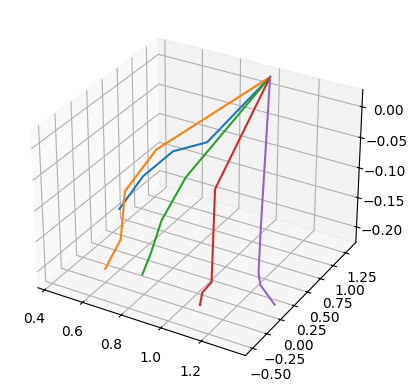

In [2]:
plot_hand(keypoints)

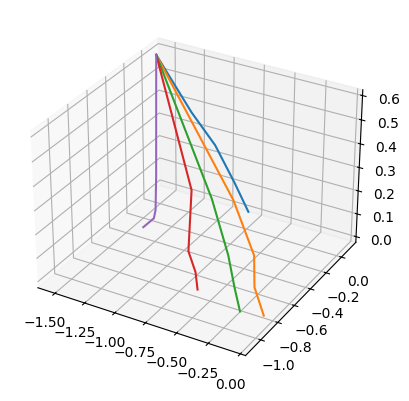

In [44]:
def Hflip(keypoints):
    """Flip human joints horizontally.

    Note:
        num_keypoints: K
        num_dimension: D
    Args:
        keypoints (np.ndarray([K, D])): Coordinates of keypoints.
        flip_pairs (list[tuple()]): Pairs of keypoints which are mirrored
            (for example, left ear -- right ear).
    Returns:
        keypoints_flipped
    """
    keypoints_flipped = keypoints

    # get palm plane (hand orientation vector)
    p1 = keypoints[5] - keypoints[0]
    p2 = keypoints[17] - keypoints[0]
    palm_normal = np.cross(p1, p2)
    palm_normal /= np.linalg.norm(palm_normal)

    # # get hand lengthwise axis
    # hand_axis = keypoints[9] - keypoints[0]
    hand_axis = keypoints[5] - keypoints[17]
    hand_axis /= np.linalg.norm(hand_axis)

    # flip keypoints across the palm plane
    # r = R.from_rotvec(np.radians(180) * palm_normal)
    # keypoints_flipped = r.apply(keypoints_flipped)

    keypoints_flipped = keypoints_flipped - 2 * np.dot(keypoints_flipped, hand_axis)[:, None] * hand_axis

    return keypoints_flipped

plot_hand(Hflip(keypoints))


In [18]:
# load up pose data
dataset_path = f'./data/CAMERA/timeseries/hand_movement_all.npz'
data = np.load(dataset_path)

kpts = np.split(data['samples_kpts_unscaled'], data['samples_unscaled_idxs'], axis=0)
labels = data['labels']

print(f'kpts: len {len(kpts)} ') #x {kpts[0].shape}')
print(f'labels: {labels.shape}')

kpts: len 120 
labels: (120, 2)


In [73]:
import cv2
from tqdm import tqdm
from IPython.display import Video

def norm_poses(clip):
    wrist = clip[:,0]
    palm_vector = ((clip[:,5] - wrist) + (clip[:,9] - wrist) + (clip[:,13] - wrist) + (clip[:,17] - wrist)) / 4
    palm_size = np.linalg.norm(palm_vector, axis=1).reshape(-1,1,1)
    mean_pos = clip.mean((0, 1), keepdims=True)
    print(clip.shape, mean_pos.shape)
    print((clip - mean_pos).mean((0, 1)))
    return (clip - mean_pos) / palm_size


# make a video from rotating view of pose
images = []
print("generating images...")
i = 20
kpts_sequence = kpts[i] #- kpts[i].mean((0,1))
# print(kpts[i].mean((0,1)).shape)
kpts_sequence = norm_poses(kpts_sequence)
print(kpts_sequence.shape)
label = labels[i]
view_angles = np.arange(180, 180+len(kpts_sequence), 0.25)
for angle, pose in tqdm(zip(view_angles, kpts_sequence)):
    # images.append(plot_hand(keypoints, view=[35, i], show_plot=True))
    images.append(plot_hand(pose, title=label, view=[35, angle], show_plot=True))
print(len(images))

# write images to video
video_outfile = './_debug_outputs/' + 'hand_rotation.mp4'
codec_fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30
frame_size = (images[0].shape[1], images[0].shape[0])
video_writer = cv2.VideoWriter(video_outfile, codec_fourcc, fps, frame_size)

print("writing video...")
for image in tqdm(images):
    video_writer.write(image[..., :3])
video_writer.release()
print("video saved to: ", video_outfile)

# Video(video_outfile, width=frame_size[0], height=frame_size[1])

generating images...
(180, 21, 3) (1, 1, 3)
[-9.21073917e-17 -3.00758830e-17 -2.58464619e-18]
(180, 21, 3)


180it [00:35,  5.07it/s]


180
writing video...


100%|██████████| 180/180 [00:00<00:00, 346.99it/s]

video saved to:  ./_debug_outputs/hand_rotation.mp4


# display the video
<video src='./_debug_outputs/hand_rotation.mp4'>